# Introduction to Active Particle Systems

## Overview

### Questions

* How can we model particles with self-induced **active forces**?
* What types of phase diagrams can we encounter when investigating **non-equilibrium** systems?

### Objectives

* Write an **MD simulation** for spherical **active** particles using the **Active Brownian Particle (ABP) model** 
* Learn how to implement a **Brownian integrator** at kT = 0 with **rotational diffusion** to intialize and thermalize and active particle system that we can then visualize.


## Boilerplate Code

In [1]:
import hoomd
import itertools

import gsd.hoomd

import numpy as np

In [2]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "active.gsd")
![ -e "$fn" ] && rm "$fn"

The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [3]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if ('version' not in dir(fresnel) or packaging.version.parse(
            fresnel.version.version) < FRESNEL_MIN_VERSION
            or packaging.version.parse(
                fresnel.version.version) >= FRESNEL_MAX_VERSION):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(scene,
                                       N=len(snapshot.particles.position),
                                       radius=0.5)
    geometry.material = fresnel.material.Material(color=[0, 0, 0],
                                                  roughness=0.5,
                                                  primitive_color_mix=1.0)
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.3
    geometry.outline_width = 0.04
    box = fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1),
                            color=(0.8, 0.8, 0.8),
                            theta=np.pi),
        fresnel.light.Light(direction=(1, 1, 1),
                            color=(1.1, 1.1, 1.1),
                            theta=np.pi / 3)
    ]
    scene.camera = fresnel.camera.Orthographic(position=(L * 2, L, L * 2),
                                               look_at=(0, 0, 0),
                                               up=(0, 1, 0),
                                               height=L * 1.4 + 1)
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

## Simulating Brownian Active Particles

In this part of the tutorial we will create a simulation of **self-propelled** active particles using the **Active Brownian Particle (ABP) model**. As mentioned in part 1 of this tutorial, we can set up the initial state of the simulation in a very similar manner to previous methods we have used in [earlier hoomd MD simulation tutorials](../01-Introducing-Molecular-Dynamics/00-index.ipynb). 

## Set up the Simulation

We will first initialize a system of spherical particles with a given particle density, in an array. We save an initial snapshot of the current state of the system 

NOTE TO SELF: needed save initial GSD?

In [4]:
rho = 0.5 # particle density
simseed = 1

m = 6
N_particles = m**3
K = np.ceil(N_particles ** (1 / 3))
L = (N_particles / rho)**(1 / 3)
spacing = L / K
x = np.linspace(-L / 2, L / 2, int(K), endpoint=False)
position = np.array(list(itertools.product(x, repeat=3)))
position = np.array(position) + [spacing / 2, spacing / 2, spacing / 2]

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position[0:N_particles, :]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.types = ['A']
frame.particles.mass = [1] * N_particles
frame.particles.orientation = [1,0,0,0] * N_particles

with gsd.hoomd.open(name='lattice.gsd', mode='w') as f:
    f.append(frame)

Configure this simulation to run on CPU from this snapshot as we have in previous tutorials.

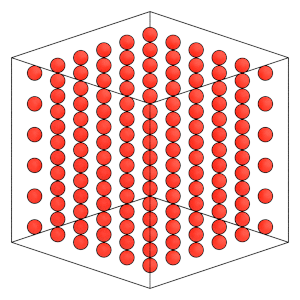

In [5]:
cpu = hoomd.device.CPU()
sim = hoomd.Simulation(device=cpu, seed=simseed)
state = sim.create_state_from_gsd(filename='lattice.gsd')
render(sim.state.get_snapshot())

## Defining Interactions in an Active Particle system

The pair interactions added to the integrator 

Active force with rotational diffusion updater

Note: Add stuff about why rotational diffusion updater. (ie. insert stuff here about the difference between run and tumble and active brownian particle (ABP) models. 

Good figure and descript in [this paper](https://www.annualreviews.org/content/journals/10.1146/annurev-conmatphys-031214-014710))



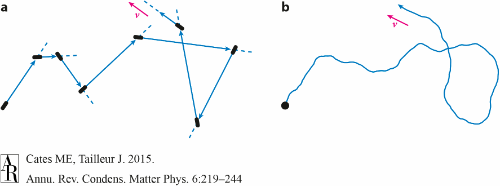
a. run and tumble b. brownian

In [6]:
integrator = hoomd.md.Integrator(dt=0.001, integrate_rotational_dof=False)
sim.operations.integrator = integrator

Add the short range Lennard Jones (WCA) pair potential interactions between particles.

In [7]:
LJ_sigma = 1
LJ_epsilon = 1

cell = hoomd.md.nlist.Cell(buffer=0.4, exclusions=['body'])
wca = hoomd.md.pair.LJ(nlist=cell, default_r_cut=(2**(1/6))*LJ_sigma, default_r_on=0.0, mode='shift')
wca.params[('A', 'A')] = {'sigma': LJ_sigma, 'epsilon': LJ_epsilon}

integrator.forces.append(wca)

Set up the brownian integrator

In [8]:
kT = 0
gamma = 1

filter_all = hoomd.filter.All()
brownian = hoomd.md.methods.Brownian(filter=filter_all, kT=kT)
brownian.gamma.default = gamma
brownian.gamma_r.default = [gamma,gamma,gamma]
integrator.methods.append(brownian)

In [9]:
activity = 0.3

active = hoomd.md.force.Active(filter=filter_all)
active.active_force['A'] = (activity,0,0)
active.active_torque['A'] = (0,0,0)

integrator.forces.append(active)

rotational_diffusion_updater = active.create_diffusion_updater(
    trigger=1, rotational_diffusion = 0.1)
sim.operations += rotational_diffusion_updater

Run the Simulation and get initial snapshot

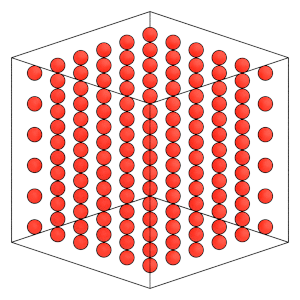

In [10]:
logger = hoomd.logging.Logger(['particle','constraint'])
gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(100)), filename='active.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=hoomd.filter.All())

sim.operations += gsd_oper

sim.state.thermalize_particle_momenta(filter=filter_all, kT=kT)
sim.run(0)
render(sim.state.get_snapshot())

Thermalize the system

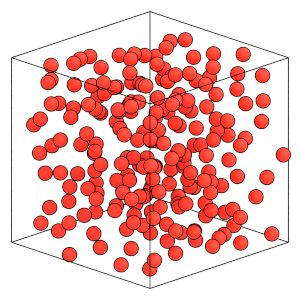

In [11]:
sim.run(10000)
gsd_oper.flush()
render(sim.state.get_snapshot())

Compress the system to see if we can see MIPS


MIPS: motility induced phase separation
- purely repulsive active particles --> phase transition to gas-liquid coexistance
- 

Note: Insert info about mips here
- rho cannot exceed rho*, the close packed density.
- https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.126.188002

TO DO:
- fix box deprecation error
- my mips aint MIPS-ing right now


In [12]:
initial_rho = sim.state.N_particles / sim.state.box.volume
final_rho = 0.7

initial_box = sim.state.box
final_box = hoomd.Box.from_box(initial_box)  # make a copy of initial_box
final_box.volume = sim.state.N_particles / final_rho

ramp = hoomd.variant.Ramp(A=0, B=1, t_start=sim.timestep, t_ramp=20000)
box_resize_trigger = hoomd.trigger.Periodic(10)

box_resize = hoomd.update.BoxResize(
    box1=initial_box, box2=final_box, variant=ramp, trigger=box_resize_trigger
)
sim.operations.updaters.append(box_resize)

/Users/katejensen/mambaforge/envs/flex_hoomd_v4_9_1/lib/python3.13/site-packages/hoomd/update/box_resize.py:147: FutureWarning: box1, box2, and variant are deprecated, use `box`
  warnings.warn('box1, box2, and variant are deprecated, use `box`',


timestep:  110000
timestep:  210000
timestep:  310000
timestep:  410000
timestep:  510000
timestep:  610000
timestep:  710000
timestep:  810000
timestep:  910000
timestep:  1010000
timestep:  1110000
timestep:  1210000
timestep:  1310000
timestep:  1410000
timestep:  1510000


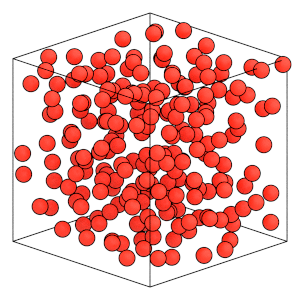

In [13]:
for i in range(5):
    sim.run(100000)
    gsd_oper.flush()
    print('timestep: ', sim.timestep)

render(sim.state.get_snapshot())